# **Introduction to Time series**

A **time series** is a sequence of data points recorded or measured at successive points in time, usually at uniform intervals. Time series analysis involves methods for analyzing these data points to extract meaningful statistics and identify characteristics of the data.

**Components of Time Series**

1. **Trend Component (T):** Represents the general direction or pattern of the data over a long period.
2. **Seasonal Component (S)**: Captures the periodic fluctuations within a specific period (e.g., quarterly sales).
3. **Cyclic Component (C)**: Refers to long-term oscillations that are not necessarily periodic.
4. **Irregular Component (I)**: Random or residual variations after accounting for trend, seasonality, and cyclic components.
Decomposition of Time Series

Time series can be decomposed into its components using either additive or multiplicative models:

1. **Additive Model: Y(t)=T(t)+S(t)+C(t)+I(t)**
Data has same width and height of the seasonal patterns or peaks. Trend of the data is linear.

2. **Multiplicative Model: Y(t)=T(t)×S(t)×C(t)×I(t)**
Data has increasing / decreasing width and height of the seasonal patterns or peaks. Trend of the data is non-linear.

**About the dataset**

This dataset contain 3 columns :

1. Date of transaction

2. Volumne in lakhs

3. Value in INR Crores

# **EXPLORATORY ANALYSIS & FORECASTING**

## Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from datetime import datetime

In [2]:
from statsmodels.tsa.arima.model import ARIMA
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings("ignore")

In [3]:
# Loading dataset
df = pd.read_csv('/content/UPI transaction data.csv')

In [4]:
# Let's see first 5 rows
df.head(5)

,Date,Vol,Val
0,"June 1, 2020",476.97,10413.11
1,"June 2, 2020",476.78,9951.30
2,"June 3, 2020",456.26,9622.38
3,"June 4, 2020",463.05,9639.50
4,"June 5, 2020",464.79,9539.52


In [5]:
# Let's see last 5 rows
df.tail(5)

,Date,Vol,Val
1486,"June 26, 2024",4481.40,62349.06
1487,"June 27, 2024",4504.87,62009.24
1488,"June 28, 2024",4527.52,66808.91
1489,"June 29, 2024",4755.43,70499.43
1490,"June 30, 2024",4619.75,59293.86


In [6]:
# Converting date to pandas datetime
df['Date'] = pd.to_datetime(df['Date'])
# Now index will be Date
df.set_index('Date', inplace=True)

Why we do this:

Time series data should have dates in datetime format.

We set the date as the index so that Python can treat it as a time series.

Sorting is necessary so that our analysis is in correct order (oldest to newest).

In [7]:
# Checking shape of dataset
df.shape

(1491, 2)

In [8]:
# Checking null values
df.isnull().sum()

,0
Vol,0
Val,0


In [9]:
# various statistical measures
df.describe()

,Vol,Val
count,1491.000000,1491.000000
mean,2160.439611,34927.247458
std,1266.795148,18632.921051
min,289.000000,4333.740000
25%,929.760000,18035.945000
50%,1972.090000,33487.990000
75%,3136.965000,48262.555000
max,4840.870000,84201.750000


**Basic Plotting of the Time Series**

In [10]:
# Plot of volume vs date
fig = px.line(df, x=df.index, y="Vol")
fig.show()

In [11]:
# Plot of value vs date
fig = px.line(df, x=df.index, y="Val")
fig.show()

In [12]:
# Barplot of volume vs year
df_year = df.groupby(df.index.year)['Vol'].sum()
fig = px.bar(df_year, x=df_year.index, y='Vol', title='Volume per Year')
fig.update_layout(
    xaxis_title='Year',
    yaxis_title='Volume'
)
fig.show()

In [13]:
# Barplot of value vs year
df_year = df.groupby(df.index.year)['Val'].sum()
fig = px.bar(df_year, x=df_year.index, y='Val', title='Value per Year')
fig.update_layout(
    xaxis_title='Year',
    yaxis_title='Value'
)
fig.show()

**Monthly data**

In [14]:
# Grouping by month and summing the 'Vol' column
df_monthly = df.resample('M').sum()

In [15]:
# Plotting with Plotly Express
df_monthly.index = df_monthly.index.strftime('%B %Y')
fig = px.line(df_monthly, x=df_monthly.index, y='Vol', title='Monthly Transaction Volume')
fig.update_layout(
    xaxis_title='Month',
    yaxis_title='Transaction Volume'
)
fig.show()

In [16]:
# Plotting with Plotly Express
fig = px.line(df_monthly, x=df_monthly.index, y='Val', title='Monthly Transaction Value')
fig.update_layout(
    xaxis_title='Month',
    yaxis_title='Transaction Value'
)
fig.show()

**Weekly data**

In [17]:
# Grouping by week and summing the 'Vol' column
df_weekly = df.resample('W').sum()

In [18]:
# Plotting with Plotly Express
fig = px.line(df_weekly, x=df_weekly.index, y='Vol', title='Weekly Transaction Volume')
fig.update_layout(
    xaxis_title='Week',
    yaxis_title='Transaction Volume'
)
fig.show()

In [19]:
# Plotting with Plotly Express
fig = px.line(df_weekly, x=df_weekly.index, y='Val', title='Weekly Transaction Value')
fig.update_layout(
    xaxis_title='Week',
    yaxis_title='Transaction Value'
)
fig.show()

**Let's find the period of Seasonality**

In [20]:
# Perform Fourier Transform
fft_vals = np.fft.fft(df['Vol'])
fft_freqs = np.fft.fftfreq(len(df))

# Only keep the positive frequencies
positive_freqs = fft_freqs[fft_freqs >= 0]
positive_vals = np.abs(fft_vals[fft_freqs >= 0])

fig = px.line(y= positive_vals, x=positive_freqs, title='Periodogram')
fig.update_layout(
    xaxis_title='Frequency',
    yaxis_title='Amplitude'
)
fig.show()

From the above we can see there is a peak at x = 0.032 which is equal to 1/Period. Therefore Seasonal Period of "Vol" data can be taken as 30.

In [21]:
# Perform Fourier Transform
fft_vals = np.fft.fft(df['Val'])
fft_freqs = np.fft.fftfreq(len(df))

# Only keep the positive frequencies
positive_freqs = fft_freqs[fft_freqs >= 0]
positive_vals = np.abs(fft_vals[fft_freqs >= 0])

fig = px.line(y= positive_vals, x=positive_freqs, title='Periodogram')
fig.update_layout(
    xaxis_title='Frequency',
    yaxis_title='Amplitude'
)
fig.show()

Again from the above we can see there is a peak at x = 0.032 which is equal to 1/Period. Therefore Seasonal Period of "Val" data can be taken as 30.

**Let's decompose our data to see Trend, Seasonality and Irregular components.**

In [22]:
import statsmodels.api as sm
import statsmodels.tsa.api as smt

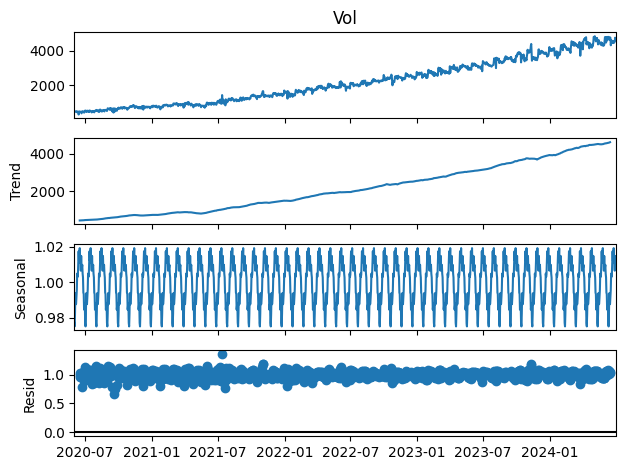

In [23]:
dec = sm.tsa.seasonal_decompose(df['Vol'],period = 30, model = 'multiplicative').plot()
plt.show()

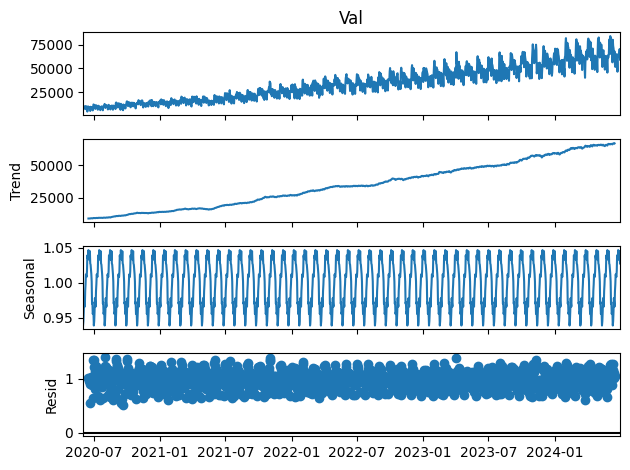

In [24]:
dec = sm.tsa.seasonal_decompose(df['Val'],period = 30, model = 'multiplicative').plot()
plt.show()

# Defining important functions

**Defining Dickey-Fuller test for Stationarity**

In [26]:
#Ho: It is non stationary
#H1: It is stationary
from statsmodels.tsa.stattools import adfuller

def adfuller_test(col):
    result=adfuller(col)
    labels = ['ADF Test Statistic','p-value','#Lags Used','Number of Observations Used']
    for value,label in zip(result,labels):
        print(label+' : '+str(value) )
    if result[1] <= 0.05:
        print("strong evidence against the null hypothesis(Ho), reject the null hypothesis. Data has no unit root and is stationary")
    else:
        print("weak evidence against null hypothesis, time series has a unit root, indicating it is non-stationary ")


For "Vol" data

In [27]:
adfuller_test(df['Vol'])

ADF Test Statistic : 1.9914203313883792
p-value : 0.9986616986026696
#Lags Used : 24
Number of Observations Used : 1466
weak evidence against null hypothesis, time series has a unit root, indicating it is non-stationary 


For "Val" data

In [28]:
adfuller_test(df['Val'])

ADF Test Statistic : -0.3564569648359333
p-value : 0.917119001228093
#Lags Used : 24
Number of Observations Used : 1466
weak evidence against null hypothesis, time series has a unit root, indicating it is non-stationary 


**Differencing (x_t - x_t-30)**

In [29]:
df['Vol_1st_diff'] = df['Vol'].diff(periods = 30)

adfuller_test(df['Vol_1st_diff'][30:])


ADF Test Statistic : -5.334530715757761
p-value : 4.642310952726284e-06
#Lags Used : 23
Number of Observations Used : 1437
strong evidence against the null hypothesis(Ho), reject the null hypothesis. Data has no unit root and is stationary


In [30]:
df['Vol_1st_diff'][30:].head()

,Vol_1st_diff
Date,
2020-07-01,38.21
2020-07-02,5.18
2020-07-03,51.15
2020-07-04,35.72
2020-07-05,-32.27


In [31]:
fig = px.line(df, x=df.index, y="Vol_1st_diff")
fig.show()

In [32]:
df['Val_1st_diff'] = df['Val'].diff(periods = 30)

adfuller_test(df['Val_1st_diff'][30:])

ADF Test Statistic : -6.319466635884541
p-value : 3.091652806167665e-08
#Lags Used : 22
Number of Observations Used : 1438
strong evidence against the null hypothesis(Ho), reject the null hypothesis. Data has no unit root and is stationary


In [33]:

df['Val_1st_diff'][30:].head()

,Val_1st_diff
Date,
2020-07-01,1198.60
2020-07-02,543.14
2020-07-03,1113.07
2020-07-04,475.08
2020-07-05,-2424.47


In [34]:
fig = px.line(df, x=df.index, y="Val_1st_diff")
fig.show()

In [35]:
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf

# Model fitting
**ACF & PACF Plots for "Vol" and "Val" data**

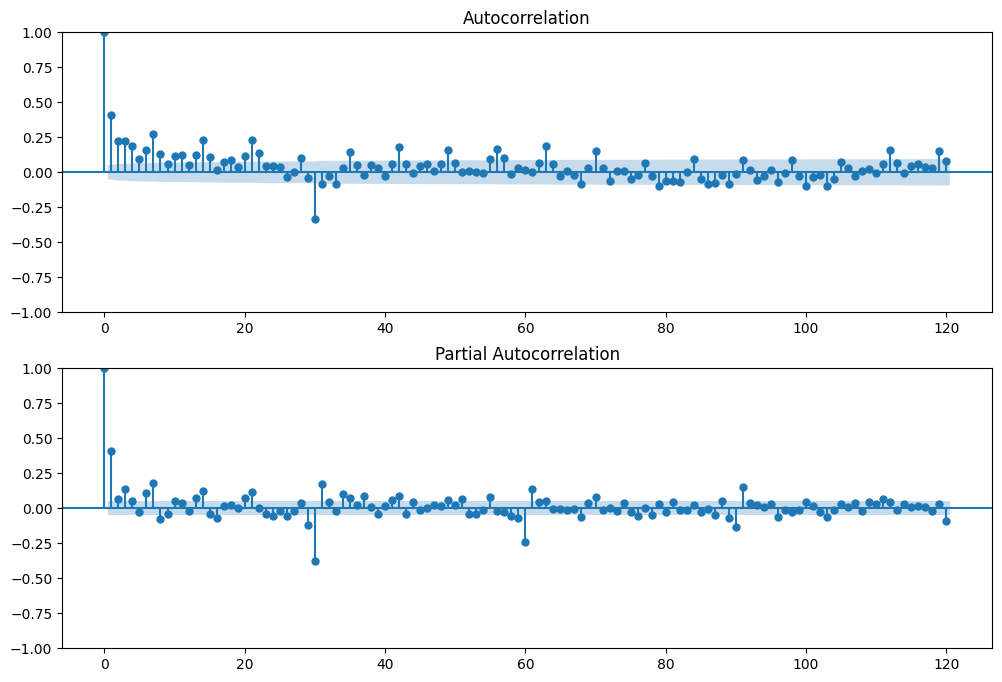

In [36]:
fig = plt.figure(figsize=(12,8))
ax1 = fig.add_subplot(211)
fig = sm.graphics.tsa.plot_acf(df['Vol_1st_diff'].iloc[30:],lags=120,ax=ax1)
ax2 = fig.add_subplot(212)
fig = sm.graphics.tsa.plot_pacf(df['Vol_1st_diff'].iloc[30:],lags=120,ax=ax2)

**Splitting Dataset**

In [37]:

# Split the data into train and test sets
train_size = int(len(df) * 0.8)
train_Vol, test_Vol = df['Vol'].iloc[:train_size], df['Vol'].iloc[train_size:]
train_Val, test_Val = df['Val'].iloc[:train_size], df['Val'].iloc[train_size:]

# ARIMA(p,d,q)

**For Volume**

In [38]:
# Fit ARIMA model
# (p, d, q) are the parameters of the ARIMA model. You can adjust these parameters or use auto_arima to determine the best parameters.
model = ARIMA(train_Vol, order=(3, 1, 1))
model_fit = model.fit()

In [39]:
# Print summary of the model
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                    Vol   No. Observations:                 1192
Model:                 ARIMA(3, 1, 1)   Log Likelihood               -6861.000
Date:                Sat, 03 May 2025   AIC                          13731.999
Time:                        20:15:26   BIC                          13757.412
Sample:                    06-01-2020   HQIC                         13741.575
                         - 09-05-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4340      0.032     13.709      0.000       0.372       0.496
ar.L2          0.1709      0.031      5.519      0.000       0.110       0.232
ar.L3          0.0883      0.028      3.098      0.0

In [40]:
# Make predictions
predictions = model_fit.forecast(steps=len(test_Vol))
predictions = pd.Series(predictions, index=test_Vol.index)

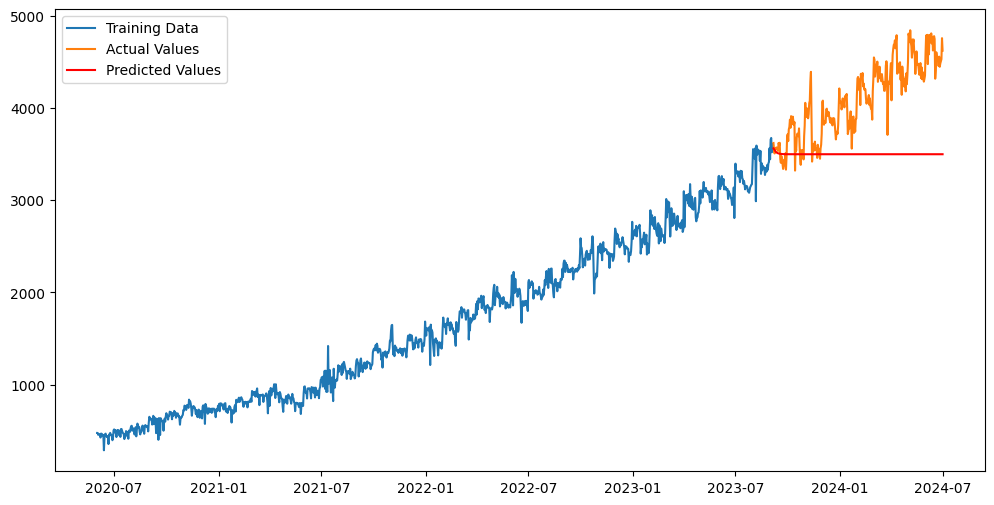

In [41]:
# Plot actual vs predicted values
plt.figure(figsize=(12, 6))
plt.plot(train_Vol, label='Training Data')
plt.plot(test_Vol, label='Actual Values')
plt.plot(predictions, label='Predicted Values', color='red')
plt.legend()
plt.show()

In [42]:
pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 20.8 MB/s eta 0:00:00


**For Value**

In [43]:
# Fit ARIMA model
# (p, d, q) are the parameters of the ARIMA model. You can adjust these parameters or use auto_arima to determine the best parameters.
model = ARIMA(train_Val, order=(2, 1, 1))
model_fit = model.fit()

In [44]:
# Print summary of the model
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                    Val   No. Observations:                 1192
Model:                 ARIMA(2, 1, 1)   Log Likelihood              -11685.321
Date:                Sat, 03 May 2025   AIC                          23378.642
Time:                        20:15:46   BIC                          23398.972
Sample:                    06-01-2020   HQIC                         23386.303
                         - 09-05-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3456      0.022     15.409      0.000       0.302       0.390
ar.L2          0.1331      0.030      4.412      0.000       0.074       0.192
ma.L1         -0.9612      0.011    -90.940      0.0

In [45]:
# Make predictions
predictions = model_fit.forecast(steps=len(test_Val))
predictions = pd.Series(predictions, index=test_Val.index)

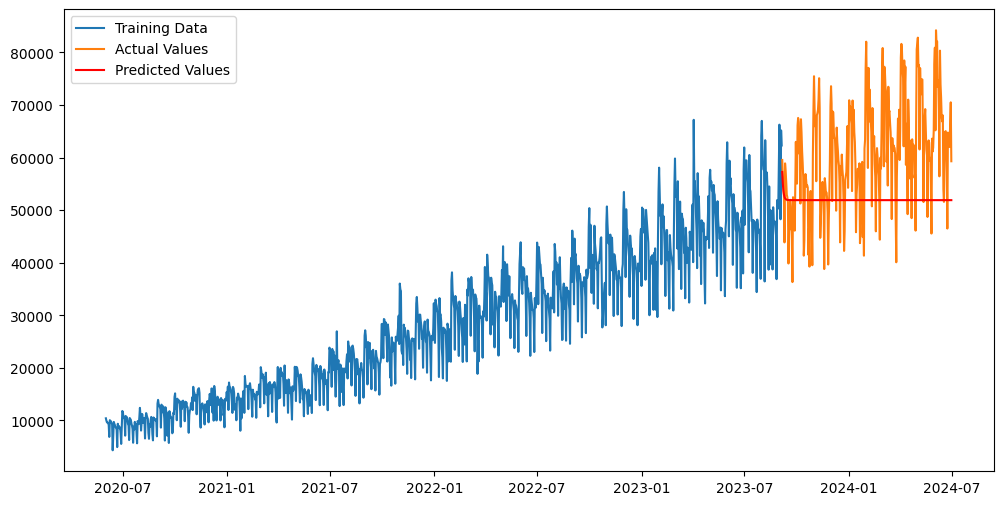

In [46]:
# Plot actual vs predicted values
plt.figure(figsize=(12, 6))
plt.plot(train_Val, label='Training Data')
plt.plot(test_Val, label='Actual Values')
plt.plot(predictions, label='Predicted Values', color='red')
plt.legend()
plt.show()

In [47]:

from sklearn.metrics import mean_squared_error, mean_absolute_error
# Fit ARIMA model for 'Val'
model_val = ARIMA(train_Val, order=(2, 1, 1))  # Adjust p, d, q as needed
model_val_fit = model_val.fit()
print("Summary of ARIMA model for 'Val':")
print(model_val_fit.summary())

# Make predictions for 'Val'
predictions_val = model_val_fit.forecast(steps=len(test_Val))
predictions_val = pd.Series(predictions_val, index=test_Val.index)

# Calculate MSE and MAE for 'Val'
mse_val = mean_squared_error(test_Val, predictions_val)
mae_val = mean_absolute_error(test_Val, predictions_val)

print(f"MSE for 'Val': {mse_val}")
print(f"MAE for 'Val': {mae_val}")

# Fit ARIMA model for 'Vol'
model_vol = ARIMA(train_Vol, order=(3, 1, 1))  # Adjust p, d, q as needed
model_vol_fit = model_vol.fit()
print("Summary of ARIMA model for 'Vol':")
print(model_vol_fit.summary())

# Make predictions for 'Vol'
predictions_vol = model_vol_fit.forecast(steps=len(test_Vol))
predictions_vol = pd.Series(predictions_vol, index=test_Vol.index)

# Calculate MSE and MAE for 'Vol'
mse_vol = mean_squared_error(test_Vol, predictions_vol)
mae_vol = mean_absolute_error(test_Vol, predictions_vol)

print(f"MSE for 'Vol': {mse_vol}")
print(f"MAE for 'Vol': {mae_vol}")


Summary of ARIMA model for 'Val':
                               SARIMAX Results                                
Dep. Variable:                    Val   No. Observations:                 1192
Model:                 ARIMA(2, 1, 1)   Log Likelihood              -11685.321
Date:                Sat, 03 May 2025   AIC                          23378.642
Time:                        20:15:58   BIC                          23398.972
Sample:                    06-01-2020   HQIC                         23386.303
                         - 09-05-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3456      0.022     15.409      0.000       0.302       0.390
ar.L2          0.1331      0.030      4.412      0.000       0.074       0.192
ma.L1         -0.9

# MODEL 2: Random Forest (Machine Learning)
**Prepare Features**

**Random Forest** is a machine learning algorithm that builds multiple decision trees and combines their outputs for better accuracy.

Lag values help the model understand time-based patterns — e.g., if last month's transaction volume affects this month.

Month/year features let the model learn seasonal or yearly effects.

We use RMSE and MAE to evaluate how well our predictions match actual values:

1. RMSE shows the average prediction error in the same unit as the target.

2. MAE shows the average absolute difference.

In [48]:
# Machine Learning
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split

Number of outliers: 0


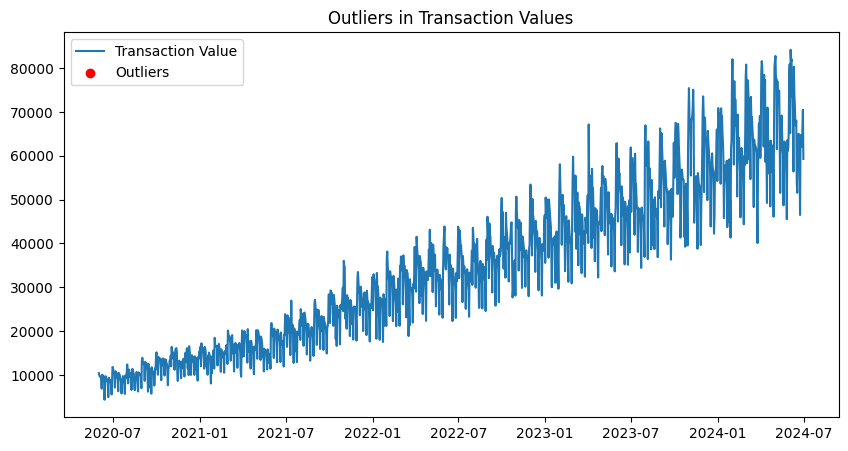

In [49]:
# Detecting Outliers using IQR
Q1 = df['Val'].quantile(0.25)
Q3 = df['Val'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter out the outliers
outliers = df[(df['Val'] < lower_bound) | (df['Val'] > upper_bound)]

# Show how many outliers
print(f"Number of outliers: {len(outliers)}")

# Plot with outliers
plt.figure(figsize=(10, 5))
plt.plot(df['Val'], label='Transaction Value')
plt.scatter(outliers.index, outliers['Val'], color='red', label='Outliers')
plt.legend()
plt.title('Outliers in Transaction Values')
plt.show()

# Optional: Remove outliers
df_clean = df[(df['Val'] >= lower_bound) & (df['Val'] <= upper_bound)]


RMSE: 5336.14
MAE: 4341.58


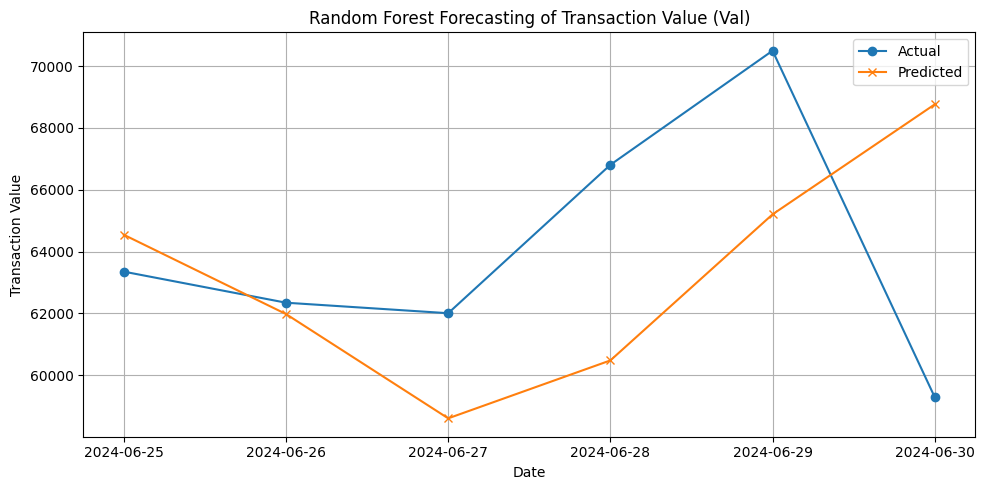

In [50]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

# 1. Load and clean the dataset
df = pd.read_csv("UPI transaction data.csv")

# Strip any spaces from column names
df.columns = df.columns.str.strip()

# Convert Date column to datetime format
df['Date'] = pd.to_datetime(df['Date'])

# Set the Date column as the index
df.set_index('Date', inplace=True)

# 2. Create new features (lag values and date-based features)
df_model = df.copy()
df_model['month'] = df_model.index.month          # Extract month from date
df_model['year'] = df_model.index.year            # Extract year from date
df_model['lag_1'] = df_model['Val'].shift(1)      # Previous month
df_model['lag_2'] = df_model['Val'].shift(2)      # Two months ago
df_model['lag_3'] = df_model['Val'].shift(3)      # Three months ago

# Drop any rows with missing values due to lagging
df_model = df_model.dropna()

# 3. Define features and target
features = ['month', 'year', 'lag_1', 'lag_2', 'lag_3']
target = 'Val'

X = df_model[features]
y = df_model[target]

# 4. Split data: use last 6 months for testing
train_size = len(df_model) - 6
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

# 5. Train the Random Forest model
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# 6. Predict on test data
y_pred = rf.predict(X_test)

# 7. Evaluate the model
rmse = np.sqrt(mean_squared_error(y_test, y_pred))  # Root Mean Squared Error
mae = mean_absolute_error(y_test, y_pred)           # Mean Absolute Error

print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")

# 8. Plot actual vs predicted values
plt.figure(figsize=(10, 5))
plt.plot(y_test.index, y_test, label='Actual', marker='o')
plt.plot(y_test.index, y_pred, label='Predicted', marker='x')
plt.title('Random Forest Forecasting of Transaction Value (Val)')
plt.xlabel('Date')
plt.ylabel('Transaction Value')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


RMSE: 75.14
MAE: 56.54


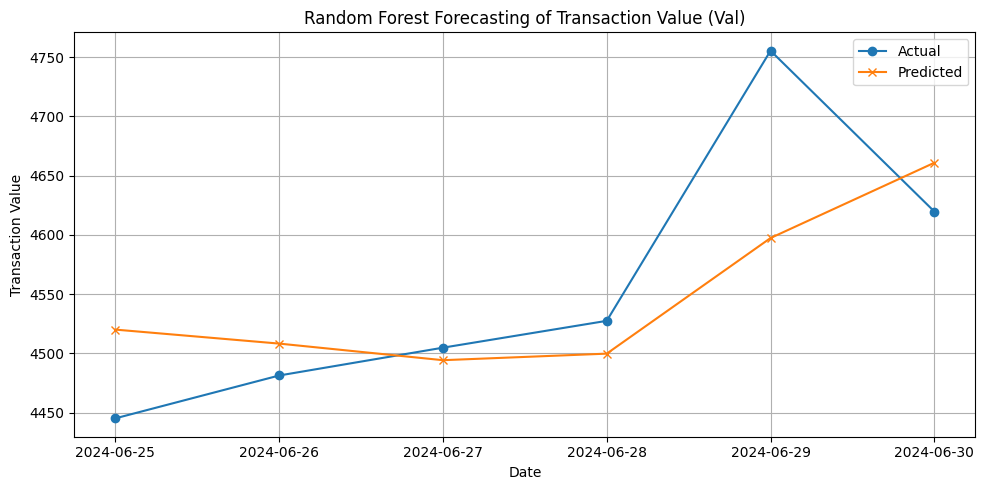

In [53]:
# 3. Define features and target
features = ['month', 'year', 'lag_1', 'lag_2', 'lag_3']
target = 'Vol'

X = df_model[features]
y1 = df_model[target]

# 4. Split data: use last 6 months for testing
train_size = len(df_model) - 6
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y1_train, y1_test = y1.iloc[:train_size], y1.iloc[train_size:]

# 5. Train the Random Forest model
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y1_train)

# 6. Predict on test data
y1_pred = rf.predict(X_test)

# 7. Evaluate the model
rmse = np.sqrt(mean_squared_error(y1_test, y1_pred))  # Root Mean Squared Error
mae = mean_absolute_error(y1_test, y1_pred)           # Mean Absolute Error

print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")

# 8. Plot actual vs predicted values
plt.figure(figsize=(10, 5))
plt.plot(y1_test.index, y1_test, label='Actual', marker='o')
plt.plot(y1_test.index, y1_pred, label='Predicted', marker='x')
plt.title('Random Forest Forecasting of Transaction Value (Val)')
plt.xlabel('Date')
plt.ylabel('Transaction Value')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Model 1 : Classical Time Series Method (Holt-Winters / ARIMA)
This model is based on statistical techniques.

It captures trend and seasonality using time series components.

It works well when the data is regular, stationary, and follows identifiable patterns.

Evaluation Metrics:
MSE for 'Val': 180955619.18792912
MAE for 'Val': 11024.932643031892
MSE for 'Vol': 514219.0971157773
MAE for 'Vol': 605.4555283483778

Model 2 : Machine Learning Model (Random Forest Regressor)
This model is based on supervised learning and does not assume any time series structure.

It uses lag values (previous data points) and date features (month, year) to learn patterns.

It can capture non-linear relationships and is flexible with different types of data.

Evaluation Metrics:
RMSE: 5336.14
MAE: 4341.58
RMSE: 75.14
MAE: 56.54

Comparison & Conclusion
The classical model is easy to interpret and useful for clean, seasonal data. However, it may not capture complex patterns.

The machine learning model (Random Forest) can handle more complex relationships but requires more feature engineering (lags, date parts).

### **Part 2 :**

If this data set had more than one variable influencing UPI transactions (e.g., inflation, festivals, app usage),
I would employ a multivariate model such as VAR (Vector AutoRegression) or LSTM-based deep learning models.

The models can employ several features collectively to enhance forecast performance.